In [1]:
import numpy as np
import gmsh
import dolfinx
import ufl
import bempp_cl.api
import petsc4py
import scipy.sparse

from bempp_cl.api.external import fenicsx
from dolfinx import fem, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from dolfinx.io import gmshio
from mpi4py import MPI
from dolfinx import io

from dolfinx.geometry import compute_colliding_cells, compute_collisions_points
from scipy.sparse import coo_matrix, diags
from petsc4py import PETSc

from coupled_solver.utils.generate_mesh import load_dolfin_mesh
from coupled_solver.utils.generate_mesh import build_boundary_mesh

from bempp_cl.api.operators.boundary import sparse, laplace, modified_helmholtz
from bempp_cl.api.assembly.blocked_operator import BlockedDiscreteOperator
from bempp_cl.api.assembly.discrete_boundary_operator import InverseSparseDiscreteBoundaryOperator
from bempp_cl.api.operators.potential.laplace import single_layer, double_layer

from scipy.sparse.linalg import LinearOperator
from scipy.sparse.linalg import gmres

x_q = np.array([[1e-12,1e-12,1e-12],[1.,0.414213562,1.],[-1.,-1.,0.414213562]]) #Ubicación de las cargas puntuales.
q   = np.array([1,-1,-1]) #Corresponde a un arreglo de N elementos, con la magnitud de las cargas puntuales.
d_scaled   = np.array([[0.,1.,0.],[1.,0.,0.],[0.,0.,-1.]]) # Dipolos
Q_scaled   = np.array([[[1.,0.,0.],[0.,-1.,0.],[0.,0.,0.]],[[0.,0.,0.],[0.,1.,0.],[0.,0.,-1.]],[[1.,0.,0.],[0.,0.,0.],[0.,0.,-1.]]]) # Cuadrupolos
alpha = np.array([[[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]],[[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]],[[1.,0.,0.],[0.,1.,0.],[0.,0.,1.]]]) # Polarizabilidad

ep_in = 1   # Permitividad dieléctrica soluto.
ep_ex = 80  # Permitividad dieléctrica solvente.
k = 0.125   # Inverso de la longitud de Debye

bohr = 0.52917721067 
d = d_scaled * bohr
Q = Q_scaled * 2 * bohr**2

N = x_q.shape[0]
mu = np.zeros((N,3))

In [2]:
### Cargar la malla para comparar

mesh, cell_tags, facet_tags = load_dolfin_mesh('sphere_4')

Loading volumetric mesh from /home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_4.msh
Info    : Reading '/home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_4.msh'...
Info    : 4 entities
Info    : 21392 nodes
Info    : 117414 elements
Info    : Done reading '/home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_4.msh'           


In [3]:
tdim = mesh.topology.dim
fdim = tdim - 1

In [4]:
mesh.topology.create_connectivity(0, tdim)
mesh.topology.create_connectivity(tdim, 0)
mesh.topology.create_entities(fdim)
mesh.topology.create_connectivity(tdim, fdim)  # cell -> facet
mesh.topology.create_connectivity(fdim, tdim)  # facet -> cell
mesh.topology.create_connectivity(fdim, 0)     # facet -> vertex 
mesh.topology.create_entity_permutations()

## Encontrar los elementos del soluto y el solvente, esto no es necesario en el otro solver

ses_facets = facet_tags.find(1)
stern_facets = facet_tags.find(2)

solute_cells = cell_tags.find(1)
stern_cells = cell_tags.find(2)

In [5]:
## Construyo ambas mallas superficiales

def build_boundary_mesh_test(mesh, facets, cell_tags=None, inner_marker=None):
    """
    Build the boundary mesh from the facets of the volumetric mesh.
    Ensures normals point outwards from the 'inner_marker' domain.
    """
    import dolfinx
    import numpy as np
    import bempp_cl

    tdim = mesh.topology.dim
    fdim = tdim - 1

    f2c = mesh.topology.connectivity(fdim, tdim)
    boundary_geo = dolfinx.mesh.entities_to_geometry(mesh, fdim, facets, True)

    tet_indices = []
    for f in facets:
        connected_cells = f2c.links(f)
        if len(connected_cells) == 1:
            # Frontera exterior real, solo hay 1 celda
            tet_indices.append(connected_cells[0])
        elif len(connected_cells) == 2:
            # Frontera interior (SES)
            if cell_tags is None or inner_marker is None:
                raise ValueError("Para fronteras internas, indicar cell_tags e inner_marker.")
            if cell_tags.values[connected_cells[0]] == inner_marker:
                tet_indices.append(connected_cells[0])
            elif cell_tags.values[connected_cells[1]] == inner_marker:
                tet_indices.append(connected_cells[1])
            else:
                raise RuntimeError("Ninguna de las celdas conectadas pertenece al marcador interno proporcionado.")
        else:
            raise RuntimeError("Una faceta está conectada a más de 2 celdas.")
            
    tet_indices = np.array(tet_indices, dtype=np.int32)

    tet_geo = dolfinx.mesh.entities_to_geometry(mesh, tdim, tet_indices, False)
    
    bm_nodes = []
    bm_cells = []
    seen = set()
    
    def add_node(g):
        if g not in seen:
            seen.add(g)
            bm_nodes.append(g)
    
    X = mesh.geometry.x
    
    for tri_geo, tet_g in zip(boundary_geo, tet_geo):
        tri_geo = list(tri_geo)
    
        for g in tri_geo:
            add_node(int(g))
    
        tri_set = set(tri_geo)
        v_opposite = None
        for g in tet_g:
            gg = int(g)
            if gg not in tri_set:
                v_opposite = gg
                break
    
        v0, v1, v2 = X[tri_geo[0]], X[tri_geo[1]], X[tri_geo[2]]
        v3 = X[v_opposite]
    
        normal = np.cross(v1 - v0, v2 - v0)
        to_other = v3 - v0
    
        if np.dot(normal, to_other) > 0:
            tri_geo = [tri_geo[0], tri_geo[2], tri_geo[1]]
    
        bm_cells.append(tri_geo)
    
    node_map = {g: i for i, g in enumerate(bm_nodes)}
    cells = np.array([[node_map[g] for g in tri] for tri in bm_cells], dtype=np.int64).T
    coords = X[np.array(bm_nodes, dtype=np.int64)].T
    
    grid = bempp_cl.api.Grid(coords, cells)
    
    if mesh.comm.rank == 0:
        print(f"Boundary mesh created: {grid.number_of_elements} elements, {grid.number_of_vertices} vertices")
    
    return grid, bm_nodes

ses_mesh, ses_nodes = build_boundary_mesh_test(mesh, ses_facets, cell_tags=cell_tags, inner_marker=1)
stern_mesh, stern_nodes = build_boundary_mesh(mesh, stern_facets)

Boundary mesh created: 830 elements, 417 vertices
Boundary mesh created: 1128 elements, 566 vertices


In [6]:
# Generar los espacios, este modelo necesita muchos más espacios

from coupled_solver.utils.sphere_linear import compute_trace_matrix

fenics_space = fem.functionspace(mesh, ('Lagrange', 2)) # Espacio de funciones para FEM (H1)
P1_space = fem.functionspace(mesh, ('Lagrange', 1)) # Espacio para la condición de Neumann
dirichlet_space_ses = bempp_cl.api.function_space(ses_mesh, 'P', 1)
neumann_space_ses = bempp_cl.api.function_space(ses_mesh, 'P', 1)
dirichlet_space_stern = bempp_cl.api.function_space(stern_mesh, 'P', 1) # Espacios de funciones para BEM (H1/2)
neumann_space_stern = bempp_cl.api.function_space(stern_mesh, 'P', 1)
trace_matrix = compute_trace_matrix(fenics_space, stern_nodes)
trace_ses = compute_trace_matrix(P1_space, ses_nodes)
trace_stern = compute_trace_matrix(P1_space, stern_nodes)

fem_ndof = fenics_space.dofmap.index_map.size_global
bem_ndof = dirichlet_space_stern.global_dof_count
total_ndof = fem_ndof + bem_ndof

print("FEM dofs: {0}".format(fem_ndof))
print("BEM dofs: {0}".format(bem_ndof))
print("Total dofs: {0}".format(total_ndof))

FEM dofs: 158803
BEM dofs: 566
Total dofs: 159369


In [7]:
## Espacios funcionales de fem

u = ufl.TrialFunction(fenics_space) # función de aproximación
lam = ufl.TrialFunction(P1_space) # función P1 para los datos de frontera
v = ufl.TestFunction(fenics_space) # Función de prueba

In [8]:
## Definir operadores, aquí tambien nito más

Is = sparse.identity(dirichlet_space_ses, neumann_space_ses, neumann_space_ses)
I = sparse.identity(dirichlet_space_stern, neumann_space_stern, neumann_space_stern)
M = sparse.identity(neumann_space_stern, neumann_space_stern, dirichlet_space_stern)
    
VL = laplace.single_layer(neumann_space_ses, dirichlet_space_ses, neumann_space_ses)
KL = laplace.double_layer(dirichlet_space_ses, dirichlet_space_ses, neumann_space_ses)

VYs = modified_helmholtz.single_layer(dirichlet_space_ses, dirichlet_space_ses, dirichlet_space_ses, k);
KYs = modified_helmholtz.double_layer(neumann_space_ses, dirichlet_space_ses, dirichlet_space_ses, k);
        
VY = modified_helmholtz.single_layer(dirichlet_space_stern, dirichlet_space_stern, dirichlet_space_stern, k);
KY = modified_helmholtz.double_layer(neumann_space_stern, dirichlet_space_stern, dirichlet_space_stern, k);

In [9]:
trace_op = LinearOperator(trace_matrix.shape, lambda x:trace_matrix * x)

In [10]:
## Definir diferenciañes y el operador A

dx = ufl.Measure("dx", domain=mesh, subdomain_data=cell_tags) # cell_tags almacena ambos volumenes
ds = ufl.Measure("dS", domain=mesh, subdomain_data=facet_tags) # En caso de necesitarlo, dS es la frontera interna
ds_ext = ufl.Measure('ds', domain=mesh, subdomain_data=facet_tags) # ds es la frontera exterior, pinche fenics

A = fenicsx.FenicsOperator(ep_in*(ufl.inner(ufl.nabla_grad(u), ufl.nabla_grad(v)))*dx(1) + ep_ex*(ufl.inner(ufl.nabla_grad(u), ufl.nabla_grad(v)))*dx(2)
                                + ep_ex*k*k*ufl.inner(u, v)*dx(2))

In [11]:
## La matriz de masa hay que ensamblarla distinto

mass = lam * v * ds_ext(2)
mass_matrix = fem.petsc.assemble_matrix(fem.form(mass))
mass_matrix.assemble()

iv, jv, kv = mass_matrix.getValuesCSR()
mass_matrix_sparse = scipy.sparse.csr_matrix((kv, jv, iv), shape=mass_matrix.getSize())

In [12]:
# Se ensambla el lado izquierdo, esto cambia un poco respecto de 2 regiones

blocks = [[None,None],[None,None]]
    
blocks[0][0] = A.weak_form()
blocks[0][1] = -ep_ex * -trace_matrix.T * M.weak_form().to_sparse()
blocks[1][0] = (.5 * I - KY).weak_form() * trace_op
blocks[1][1] = VY.weak_form()
    
cterm_lhs = BlockedDiscreteOperator(np.array(blocks)) # Lado izquierdo de la ecuación

In [13]:
# Precon

P1 = diags(1./cterm_lhs[0,0].to_sparse().diagonal())
    
P2 = InverseSparseDiscreteBoundaryOperator(
            bempp_cl.api.operators.boundary.sparse.identity(
            neumann_space_stern, neumann_space_stern, neumann_space_stern).weak_form())
    
def apply_prec(x):
    
    m1 = P1.shape[0]
    m2 = P2.shape[0]
    n1 = P1.shape[1]
    n2 = P2.shape[1]
    
    res1 = P1.dot(x[:n1])
    res2 = P2.dot(x[n1:])
    
    return np.concatenate([res1, res2])
    
p_shape = (P1.shape[0] + P2.shape[0], P1.shape[1] + P2.shape[1])
P = LinearOperator(p_shape, apply_prec, dtype=np.dtype('float64'))

In [14]:
# Parte permanente del lado derecho, aqui parten los cambios wenos

@bempp_cl.api.real_callable
def charges_fun_perm(x, n, i, result):
    T2 = np.zeros((len(x_q),3,3))
    dist = x - x_q
    norm = np.sqrt(np.sum((dist*dist), axis = 1))
    T0 = 1/norm[:]
    T1 = np.transpose(dist.transpose()/norm**3)
    T2[:,:,:] = np.ones((len(x_q),3,3))[:]*dist.reshape((len(x_q),1,3))*np.transpose(np.ones((len(x_q),3,3))*dist.reshape((len(x_q),1,3)), (0,2,1))/norm.reshape((len(x_q),1,1))**5
    phi_c = np.sum(q[:]*T0[:]) + np.sum(T1[:]*d[:]) + 0.5*np.sum(np.sum(T2[:]*Q[:],axis=1))
    result[0] = phi_c/(4*np.pi*ep_in)
    
G_fun_perm = bempp_cl.api.GridFunction(dirichlet_space_ses, fun = charges_fun_perm)

## Primer Check: G_fun da igual en ambos códigos ? Debería ser identico

In [15]:
index = [0, 100, 150, 200, 250, 300, 350, 400]
shape_2r = (417,)
coeffs_2r = np.array([-0.01865327, -0.02408905, -0.01424662, -0.01663131, -0.04594429,
                        -0.02053649, -0.0581549 , -0.04257603])
coeffs_3r = G_fun_perm.coefficients[index]
diff = coeffs_3r - coeffs_2r
print(np.linalg.norm(diff))

0.024073163922737985


In [16]:
## Carga total sobre la superficie

charge_2r = -11.118335593187062
charge_3r = G_fun_perm.coefficients.sum()
print(np.abs(charge_3r - charge_2r))

9.49304848063548e-08


### Primer sintoma, los dofs están corridos, la carga total la superficie es igual en ambos casos, pero no es igual nodo a nodo, lo que quiere decir que en la construcción de la malla superficial en ambos casos puede estar difiriendo.

In [17]:
@bempp_cl.api.real_callable
def lambda_fun_perm(x, n, i, result):
    dist = x - x_q
    norm = np.sqrt(np.sum((dist*dist), axis = 1))
    dphi = np.zeros((3))
    
    T2 = np.zeros((3, 3, 3))
    
    for j in np.where(norm > 1e-10)[0]:
        T0 = -dist[j,:] / norm[j]**3    
        T1 = np.identity(3)/norm[j]**3 - 3*np.ones((3,3)) * dist[j,:] * np.transpose(np.ones((3,3)) * dist[j,:])/norm[j]**5
    
        aux = np.zeros((3,3,3))
    
        for k in range(3):
            aux[k,:,:] = np.ones((3,3)) * dist[j,:] * np.transpose(np.ones((3,3)) * dist[j,:])*dist[j,k]
        aux *= -5/norm[j]**7
    
        for k in range(3):
            aux[:,:,k] += np.identity(3) * dist[j,k] / norm[j]**5
    
        for k in range(3):
            aux[:,k,:] += np.identity(3) * dist[j,k] / norm[j]**5
    
        T2 = aux
    
        for k in range(3):
            dphi[k] += T0[k]*q[j] + np.sum(T1[k,:] * d[j,:]) + 0.5 * np.sum(np.sum(T2[k,:,:] * Q[j,:,:], axis = 1), axis = 0)
    
    dphi /=  (4*np.pi*ep_in)
    result[0] =  np.dot(n, dphi) # Derivada direccional en la dirección normal

dGdn_fun_perm = bempp_cl.api.GridFunction(dirichlet_space_ses, fun = lambda_fun_perm)

## Segundo Check: El flujo da igual en ambos códigos ? Debería ser identico tambien

In [18]:
index = [0, 100, 150, 200, 250, 300, 350, 400]
shape_2r = (417,)
coeffs_2r = np.array([0.00349999, 0.00630347, 0.00093719, 0.00227839, 0.03242881,
                    0.00332599, 0.04239852, 0.01697358])
coeffs_3r = dGdn_fun_perm.coefficients[index]
diff = coeffs_3r - coeffs_2r
print(np.linalg.norm(diff))

0.024408522641667943


In [19]:
## Flujo total sobre la superficie

flow_2r = 3.723128365552343
flow_3r = dGdn_fun_perm.coefficients.sum()
print(np.abs(flow_3r - flow_2r))

6.287496212564747e-08


### Gran sintoma !! El flujo da con signo cambiado, las normales estan apuntando en el sentido contrario.

### Actualización: Corregido, las normales ahora apuntan bien

In [20]:
# Parte invariable del lado derecho, componente armónica
hterm_rhs_perm = -(0.5*Is + KL) * G_fun_perm

In [ ]:
#--- RHS permanente componente de corrección ---#
bem_rhs = np.zeros(bem_ndof) ## Ahora BEM no tiene lado derecho

Loading volumetric mesh from /home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_1.msh
Info    : Reading '/home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_1.msh'...
Info    : 4 entities
Info    : 1756 nodes
Info    : 10095 elements
Info    : Done reading '/home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_1.msh'
Boundary mesh created: 254 elements, 129 vertices
Loading volumetric mesh from /home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_2.msh
Info    : Reading '/home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_2.msh'...
Info    : 4 entities
Info    : 3493 nodes
Info    : 19639 elements
Info    : Done reading '/home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_2.msh'
Boundary mesh created: 576 elements, 290 vertices
Loading volumetric mesh from /home/fvicencio/non-linear_solver/coupled_solver/volumetric_mesh/sphere_4.msh
Info    : Reading '/home/fvicencio/no

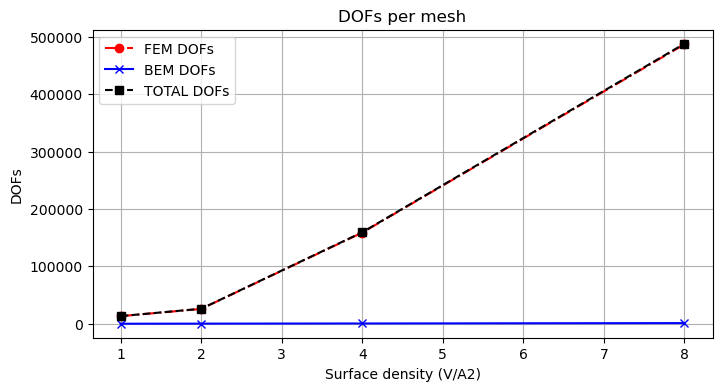

In [2]:
import numpy as np
import gmsh
import dolfinx
import ufl
import bempp_cl.api
import petsc4py
import scipy.sparse

from bempp_cl.api.external import fenicsx
from dolfinx import fem, default_scalar_type
from dolfinx.fem.petsc import LinearProblem
from dolfinx.io import gmshio
from mpi4py import MPI
from dolfinx import io

from dolfinx.geometry import compute_colliding_cells, compute_collisions_points
from scipy.sparse import coo_matrix, diags
from petsc4py import PETSc

from coupled_solver.utils.generate_mesh import load_dolfin_mesh
from coupled_solver.utils.generate_mesh import build_boundary_mesh

from bempp_cl.api.operators.boundary import sparse, laplace, modified_helmholtz
from bempp_cl.api.assembly.blocked_operator import BlockedDiscreteOperator
from bempp_cl.api.assembly.discrete_boundary_operator import InverseSparseDiscreteBoundaryOperator
from bempp_cl.api.operators.potential.laplace import single_layer, double_layer

from scipy.sparse.linalg import LinearOperator
from scipy.sparse.linalg import gmres

import matplotlib.pyplot as plt

sphere_meshes = np.array([1, 2, 4, 8])

fem_ndofs = np.zeros(len(sphere_meshes))
bem_ndofs = np.zeros(len(sphere_meshes))
tot_ndofs = np.zeros(len(sphere_meshes))

for i, j in enumerate(sphere_meshes):

    mesh_name = 'sphere_'+str(j)
    mesh, cell_tags, facet_tags = load_dolfin_mesh(mesh_name)

    tdim = mesh.topology.dim
    assert tdim == 3
    fdim = tdim - 1

    mesh.topology.create_connectivity(0, tdim)
    mesh.topology.create_connectivity(tdim, 0)
    mesh.topology.create_entities(fdim)
    mesh.topology.create_connectivity(tdim, fdim)  # cell -> facet
    mesh.topology.create_connectivity(fdim, tdim)  # facet -> cell
    mesh.topology.create_connectivity(fdim, 0)     # facet -> vertex 
    mesh.topology.create_entity_permutations()

    ses_facets = facet_tags.find(1)
    stern_facets = facet_tags.find(2)
    
    solute_cells = cell_tags.find(1)
    stern_cells = cell_tags.find(2)

    stern_mesh, stern_nodes = build_boundary_mesh(mesh, stern_facets)

    fenics_space = fem.functionspace(mesh, ('Lagrange', 2)) # Espacio de funciones para FEM (H1)
    dirichlet_space_stern = bempp_cl.api.function_space(stern_mesh, 'P', 1) # Espacios de funciones para BEM (H1/2)

    fem_ndof = fenics_space.dofmap.index_map.size_global
    bem_ndof = dirichlet_space_stern.global_dof_count
    total_ndof = fem_ndof + bem_ndof

    fem_ndofs[i] = fem_ndof
    bem_ndofs[i] = bem_ndof
    tot_ndofs[i] = total_ndof

fig, ax1= plt.subplots(figsize=(8, 4))
ax1.plot(sphere_meshes, fem_ndofs, label ='FEM DOFs', linestyle="-.",color="red", marker="o")
ax1.plot(sphere_meshes, bem_ndofs, label ='BEM DOFs', linestyle="-",color="blue", marker="x")
ax1.plot(sphere_meshes, tot_ndofs, label ='TOTAL DOFs', linestyle="--",color="black", marker="s")
ax1.set_xlabel('Surface density (V/A2)')
ax1.set_ylabel('DOFs')
ax1.set_title('DOFs per mesh')
ax1.grid(True)
ax1.legend()

In [3]:
print(fem_ndofs)
print(bem_ndofs)

[ 13283.  25916. 158803. 486509.]
[ 129.  290.  566. 1212.]
